In [ ]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Montamos Google Drive en Colab
from google.colab import drive
drive.mount('/content/drive')

RUTA_BASE = "/content/drive/MyDrive/NHANES/"

Mounted at /content/drive


Cargamos el dataset de NHANES

In [ ]:
# Dataset NHANES tras EDA
df_prep = pd.read_csv("/content/drive/MyDrive/NHANES/df_prep_NHANES.csv")

# Primeras observaciones del dataset
df_prep.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7785 entries, 0 to 7784
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         7785 non-null   float64
 1   Edad                       7785 non-null   float64
 2   Sexo                       7785 non-null   object 
 3   Raza                       7785 non-null   object 
 4   Educacion                  7760 non-null   float64
 5   Estado_civil               7762 non-null   object 
 6   Personas_hogar             7785 non-null   float64
 7   Ingresos                   6476 non-null   float64
 8   Militar                    7770 non-null   object 
 9   Altura                     5986 non-null   float64
 10  Peso                       5972 non-null   float64
 11  IMC                        5959 non-null   float64
 12  Cintura                    5752 non-null   float64
 13  Fumador_100cigs            7758 non-null   objec

In [ ]:
# Información general del dataset
df_prep.info()

No utilizaremos el id como variable predictora

In [ ]:
# Eliminamos el identificador como variable predictora
x = df_prep.drop(columns=["Stroke", "ID"])

Volvemos a agrupar las variables predictoras del dataset

In [ ]:
# Variables categóricas
var_categoricas = [
    'Sexo','Raza','Estado_civil','Militar','Fumador_100cigs',
    'Seguro_medico','Acceso_atencion_sanitaria','Hipertension',
    'Colesterol_alto','Medicacion_colesterol','Diabetes',
    'Artritis','Insuficiencia_cardiaca','Enfermedad_coronaria',
    'Angina','Infarto_miocardio','Enfisema_ChB','Enfermedad_hepatica',
    'Cancer','Problema_tiroides'
]

# Variables ordinales (convertidas a numéricas en el EDA)
var_ordinales = [
    'Educacion',
    'Alcohol_12meses',
    'Sentimiento_deprimido',
    'Estado_salud_general'
]

# Variables numéricas continuas
var_numericas = [
    col for col in df_prep.columns
    if col not in var_categoricas + var_ordinales + ['Stroke', 'ID']
]

# Variables numéricas totales (numéricas + ordinales)
var_numericas_total = var_ordinales + var_numericas

# Train - test split

Llevamos a cabo un split estratificado del dataframe en proporcion 80 - 20.

In [ ]:
from sklearn.model_selection import train_test_split

# Variables predictoras (todas menos Stroke)
x = df_prep.drop(columns=["Stroke"])

# Variable objetivo (Stroke)
y = df_prep["Stroke"]

# Split estratificado
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,      # 80% train, 20% test
    stratify=y,         # mantenemos la proporción de stroke
    random_state=24     # semilla aleatoria
)

# Copias independientes para evitar modificaciones accidentales
x_train = x_train.copy()
x_test = x_test.copy()

Comprobamos que el split estratificado se ha llevado a cabo correctamente

In [ ]:
# Dataset completo
print("Distribución en dataset completo:")
print(len(df_prep)) #Número de observaciones totales
print(y.value_counts(normalize=True)*100)

#Train
print("\nDistribución en train:")
print(len(y_train)) #Número de observaciones para train
print(y_train.value_counts(normalize=True)*100)

#Test
print("\nDistribución en test:")
print(len(y_test))
print(y_test.value_counts(normalize=True)*100)

Distribución en dataset completo:
7785
Stroke
No    95.285806
Sí     4.714194
Name: proportion, dtype: float64

Distribución en train:
6228
Stroke
No    95.279383
Sí     4.720617
Name: proportion, dtype: float64

Distribución en test:
1557
Stroke
No    95.311496
Sí     4.688504
Name: proportion, dtype: float64


# Imputación de valores faltantes

Todas las transformaciones se ajustan únicamente sobre train para evitar data leakage. El conjunto test solo se transforma usando los parámetros aprendidos en train.

## Imputación de variables numéricas

Imputamos el valor de las variables numéricas con su mediana en x_train y transformamos x_test con la misma mediana que hemos calculado en el train

In [ ]:
from sklearn.impute import SimpleImputer

#Creamos un imputador usando la mediana
imputer_num = SimpleImputer(strategy='median')

#Ajustamos SOLO en train
x_train[var_numericas_total] = imputer_num.fit_transform(x_train[var_numericas_total])

#Transformamos el test con la misma mediana que calculamos en train
x_test[var_numericas_total] = imputer_num.transform(x_test[var_numericas_total])


## Imputación de variables categóricas

Imputamos las variables categóricas usando la moda del train, asegurando así que no se "contamine" el test.

In [ ]:
# Creamos un imputador para variables categóricas a partir de la moda
imputer_cat = SimpleImputer(strategy='most_frequent')

# Ajustamos SOLO en X_train
x_train[var_categoricas] = imputer_cat.fit_transform(x_train[var_categoricas])

# Transformamos X_test con la misma moda que calculamos en X_train
x_test[var_categoricas] = imputer_cat.transform(x_test[var_categoricas])

Comprobamos que la imputación se ha llevado a cabo correctamente

In [ ]:
# Comprobamos que no quedan NaN en el train
x_train.isna().sum()

,0
ID,0
Edad,0
Sexo,0
Raza,0
Educacion,0
Estado_civil,0
Personas_hogar,0
Ingresos,0
Militar,0
Altura,0


In [ ]:
# Comprobamos que no quedan NaN en el test
x_test.isna().sum()

,0
ID,0
Edad,0
Sexo,0
Raza,0
Educacion,0
Estado_civil,0
Personas_hogar,0
Ingresos,0
Militar,0
Altura,0


# Normalización de variables numéricas

Aplicamos Min-Max scaling para transformar las variables al rango [0,1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador / normalizador
scaler = MinMaxScaler()

# Ajustamos el escalador con X_train y transformamos
x_train[var_numericas_total] = scaler.fit_transform(x_train[var_numericas_total])

# Transformamos X_test con el mismo escalador (sin recalcular min/max)
x_test[var_numericas_total] = scaler.transform(x_test[var_numericas_total])

# Revisamos resultados
print(x_train[var_numericas_total].describe().round(2))
print(x_test[var_numericas_total].describe().round(2))

       Educacion  Alcohol_12meses  Sentimiento_deprimido  \
count    6228.00          6228.00                6228.00   
mean        0.70             0.36                   0.10   
std         0.28             0.26                   0.22   
min         0.00             0.00                   0.00   
25%         0.50             0.25                   0.00   
50%         0.75             0.25                   0.00   
75%         1.00             0.50                   0.00   
max         1.00             1.00                   1.00   

       Estado_salud_general     Edad  Personas_hogar  Ingresos   Altura  \
count               6228.00  6228.00         6228.00   6228.00  6228.00   
mean                   0.59     0.56            0.26      0.57     0.50   
std                    0.26     0.29            0.24      0.30     0.13   
min                    0.00     0.00            0.00      0.00     0.00   
25%                    0.50     0.30            0.17      0.33     0.42   
50%      

In [ ]:
# Dimensiones finales
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(6228, 47)
(6228,)
(1557, 47)
(1557,)


# Encoding de variables categóricas

Aplicamos One-Hot Encoding a todas las variables categóricas, convirtiendo cada categoría de la variable en una columna binaria. De esta forma, se preserva la información sin introducir un orden artificial.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Codificamos categóricas con One-Hot
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,      # devuelve arrays densos
    handle_unknown='ignore',  # ignora categorías nuevas en test
    drop='if_binary'          # genera solo una columna para variables binarias
)
x_train_one = pd.DataFrame( # codificación del train
    encoder.fit_transform(x_train[var_categoricas]),
    index=x_train.index,
    columns=encoder.get_feature_names_out(var_categoricas)
)

x_test_one = pd.DataFrame( # codificación del test
    encoder.transform(x_test[var_categoricas]),
    index=x_test.index,
    columns=encoder.get_feature_names_out(var_categoricas)
)

# Concatenamos solo numéricas + One-Hot (sin columnas originales de texto)
x_train_encod = pd.concat([x_train[var_numericas_total], x_train_one], axis=1)
x_test_encod  = pd.concat([x_test[var_numericas_total], x_test_one], axis=1)

# Comprobamos que todo sea numérico
print(x_train_encod.dtypes.value_counts())  # deben ser solo float64


float64    54
Name: count, dtype: int64


In [ ]:
x_train_encod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6228 entries, 6454 to 570
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Educacion                     6228 non-null   float64
 1   Alcohol_12meses               6228 non-null   float64
 2   Sentimiento_deprimido         6228 non-null   float64
 3   Estado_salud_general          6228 non-null   float64
 4   Edad                          6228 non-null   float64
 5   Personas_hogar                6228 non-null   float64
 6   Ingresos                      6228 non-null   float64
 7   Altura                        6228 non-null   float64
 8   Peso                          6228 non-null   float64
 9   IMC                           6228 non-null   float64
 10  Cintura                       6228 non-null   float64
 11  Minutos_LTPA_moderada         6228 non-null   float64
 12  Minutos_sedentario            6228 non-null   float64
 13  Tiempo

In [ ]:
x_test_encod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 7039 to 4287
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Educacion                     1557 non-null   float64
 1   Alcohol_12meses               1557 non-null   float64
 2   Sentimiento_deprimido         1557 non-null   float64
 3   Estado_salud_general          1557 non-null   float64
 4   Edad                          1557 non-null   float64
 5   Personas_hogar                1557 non-null   float64
 6   Ingresos                      1557 non-null   float64
 7   Altura                        1557 non-null   float64
 8   Peso                          1557 non-null   float64
 9   IMC                           1557 non-null   float64
 10  Cintura                       1557 non-null   float64
 11  Minutos_LTPA_moderada         1557 non-null   float64
 12  Minutos_sedentario            1557 non-null   float64
 13  Tiemp

# Gestión del desbalanceo de Stroke

Guardamos un primer dataset en el que no se altera el desbalanceo de Stroke

In [ ]:
# Dataset desbalanceado
x_train_desbal = x_train_encod
y_train_desbal = y_train
x_test_final = x_test_encod
y_test_final = y_test

A la vista de los resultados obtenidos por SMOTE en el dataset de Kaggle, únicamente emplearemos Undersampling para gestionar el desbalanceo de Stroke

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Dataset desbalanceado (para class_weight)
x_train_desbal = x_train_encod.copy()
y_train_desbal = y_train.copy()

# Eliminación aleatoria de observaciones de la clase mayoritaria
rus = RandomUnderSampler(random_state=24)
x_train_under, y_train_under = rus.fit_resample(x_train_encod, y_train)

# Comparación antes y después
print("Antes:", x_train_encod.shape, y_train.value_counts().to_dict())
print("Después:", x_train_under.shape, y_train_under.value_counts().to_dict())

#Datasets finales
x_train_UNDER = x_train_under
y_train_UNDER = y_train_under

Antes: (6228, 54) {'No': 5934, 'Sí': 294}
Después: (588, 54) {'No': 294, 'Sí': 294}


Comprobamos el rendimiento de Undersampling analizando alguna de las variables más significativas del dataset en x_train

Antes de Undersampling
                                  mean       std  min  max
Educacion                     0.700425  0.283508  0.0  1.0
Alcohol_12meses               0.358462  0.256827  0.0  1.0
Sentimiento_deprimido         0.103029  0.222481  0.0  1.0
Estado_salud_general          0.592044  0.255043  0.0  1.0
Edad                          0.557972  0.291443  0.0  1.0
Personas_hogar                0.260089  0.241370  0.0  1.0
Ingresos                      0.574452  0.301869  0.0  1.0
Altura                        0.499878  0.129627  0.0  1.0
Peso                          0.247143  0.088514  0.0  1.0
IMC                           0.287951  0.100712  0.0  1.0
Cintura                       0.319636  0.114013  0.0  1.0
Minutos_LTPA_moderada         0.080197  0.074058  0.0  1.0
Minutos_sedentario            0.261780  0.152547  0.0  1.0
Tiempo_sueño                  0.475326  0.134546  0.0  1.0
PAS_media                     0.322369  0.097270  0.0  1.0
PAD_media                     0.3

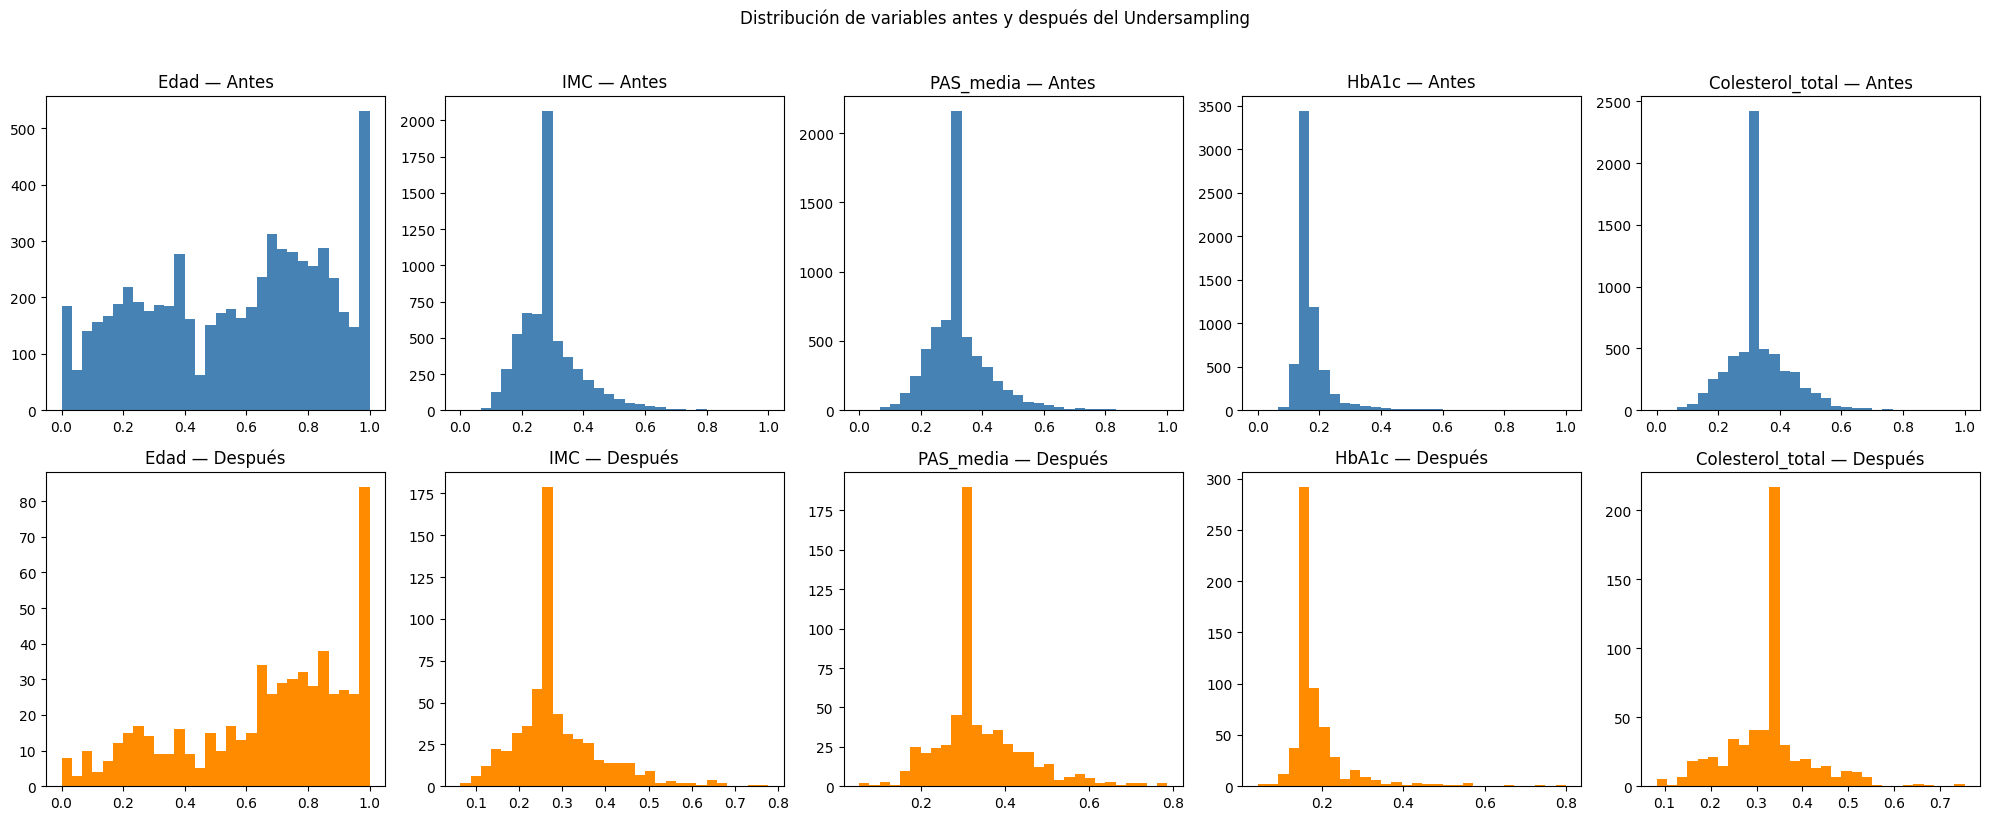

In [ ]:
# Estadísticas de variables numéricas antes
print("Antes de Undersampling")
print(x_train_encod.describe().T[['mean','std','min','max']])

# Estadísticas de variables numéricas después
print("\nDespués de Undersampling")
print(pd.DataFrame(x_train_UNDER, columns=x_train_encod.columns).describe().T[['mean','std','min','max']])

# Visualizamos las variables numéricas más relevantes antes y después del Undersampling
vars_plot = ['Edad', 'IMC', 'PAS_media', 'HbA1c', 'Colesterol_total']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, var in enumerate(vars_plot):
    # Antes de undersampling
    axes[0, i].hist(x_train_encod[var], bins=30, color='steelblue')
    axes[0, i].set_title(f'{var} — Antes')

    # Después de undersampling
    axes[1, i].hist(pd.DataFrame(x_train_UNDER, columns=x_train_encod.columns)[var], bins=30, color='darkorange')
    axes[1, i].set_title(f'{var} — Después')

plt.suptitle('Distribución de variables antes y después del Undersampling', y=1.02)
plt.tight_layout()
plt.show()

Guardamos los datasets preprocesados

In [ ]:
#Exportación de datasets finales
x_train_desbal.to_csv(RUTA_BASE + "x_train_desbal.csv",  index=False)
x_train_UNDER.to_csv( RUTA_BASE + "x_train_UNDER.csv",   index=False)
x_test_encod.to_csv(  RUTA_BASE + "x_test_final.csv",    index=False)

y_train_desbal.to_csv(RUTA_BASE + "y_train_desbal.csv",  index=False)
y_train_UNDER.to_csv( RUTA_BASE + "y_train_UNDER.csv",   index=False)
y_test.to_csv(        RUTA_BASE + "y_test_final.csv",    index=False)